# 01 — Market simulators

**What you are looking at:** the two price-path models everything downstream
runs on — geometric Brownian motion (GBM) and Heston stochastic volatility.
Each section shows sample paths, then *asserts* that simulated moments match
closed form to within tolerances derived from Monte Carlo standard errors.
If any cell raises, the simulators are broken and no later result can be
trusted; the same checks run as `uv run pytest -m gate_stage1`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from deep_hedging.simulate import GBMParams, HestonParams, simulate_gbm, simulate_heston

plt.rcParams["figure.figsize"] = (9, 4)

## Geometric Brownian motion

**What you are looking at:** GBM is the Black-Scholes model of a stock price,
$dS_t = \mu S_t\,dt + \sigma S_t\,dW_t$ — continuous compounding of
normally distributed log-returns. We simulate with the *exact* log-normal
scheme, so there is no discretization bias at any step count. Below, 30
sample paths over one year at 20% volatility.

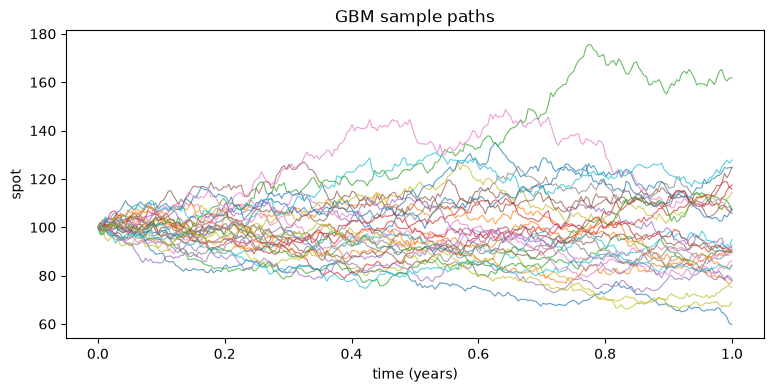

In [2]:
gbm = GBMParams(s0=100.0, mu=0.05, sigma=0.2)
paths = simulate_gbm(gbm, n_paths=30, n_steps=252, horizon=1.0, seed=7)

t = np.linspace(0, 1.0, 253)
plt.plot(t, paths.T, lw=0.8, alpha=0.7)
plt.xlabel("time (years)"); plt.ylabel("spot"); plt.title("GBM sample paths")
plt.show()

### Moment checks vs. closed form

**What you are looking at:** at $n = 100{,}000$ paths we compare the sample
mean and variance of $S_T$ against the closed forms
$\mathbb{E}[S_T] = S_0 e^{\mu T}$ and
$\mathrm{Var}[S_T] = S_0^2 e^{2\mu T}(e^{\sigma^2 T} - 1)$.
The tolerance is 4 Monte Carlo standard errors (estimated from the sample
itself — for the variance via the delta method with empirical fourth
moments), so a pass is a statistical statement, not a magic number.

In [3]:
N, T = 100_000, 1.0
s_t = simulate_gbm(gbm, n_paths=N, n_steps=8, horizon=T, seed=1001)[:, -1]

mean_cf = gbm.s0 * np.exp(gbm.mu * T)
se_mean = s_t.std(ddof=1) / np.sqrt(N)
print(f"terminal mean: sample {s_t.mean():.4f} vs closed form {mean_cf:.4f}  (SE {se_mean:.4f})")
assert abs(s_t.mean() - mean_cf) < 4 * se_mean

var_cf = gbm.s0**2 * np.exp(2 * gbm.mu * T) * (np.exp(gbm.sigma**2 * T) - 1)
centered = s_t - s_t.mean()
se_var = np.sqrt((np.mean(centered**4) - np.mean(centered**2) ** 2) / N)
print(f"terminal var:  sample {s_t.var(ddof=1):.2f} vs closed form {var_cf:.2f}  (SE {se_var:.2f})")
assert abs(s_t.var(ddof=1) - var_cf) < 4 * se_var
print("GBM moment checks passed (4 SE)")

terminal mean: sample 105.0977 vs closed form 105.1271  (SE 0.0670)
terminal var:  sample 448.31 vs closed form 451.03  (SE 2.31)
GBM moment checks passed (4 SE)


### Log-return normality and the martingale property

**What you are looking at:** left, a Q-Q plot of one-step log-returns against
the exact normal law they should follow — points on the diagonal mean the
distribution is right, and a Kolmogorov-Smirnov test asserts it. Right, the
martingale check: under the risk-neutral measure ($\mu = r$) the discounted
price $e^{-rt}S_t$ must have constant expectation $S_0$; the sample mean at
every rebalancing date should sit inside its 4-SE band.

KS p-value: 0.134


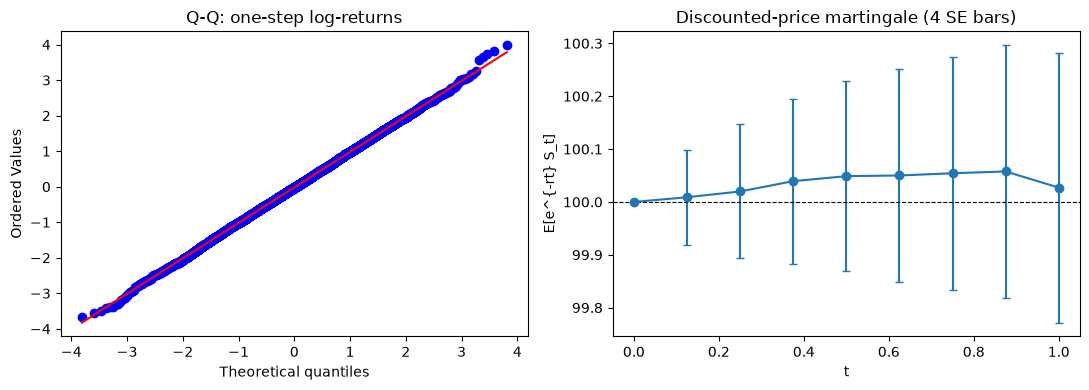

normality + martingale checks passed


In [4]:
# KS test on standardized one-step log-returns (pre-set n = 10,000)
n_ks = 10_000
p1 = simulate_gbm(gbm, n_paths=n_ks, n_steps=1, horizon=1.0, seed=1003)
log_ret = np.log(p1[:, 1] / p1[:, 0])
z = (log_ret - (gbm.mu - 0.5 * gbm.sigma**2)) / gbm.sigma
ks = stats.kstest(z, "norm")
print(f"KS p-value: {ks.pvalue:.3f}")
assert ks.pvalue > 0.01

# Martingale property under the risk-neutral measure
r, n_steps = 0.03, 8
rn = GBMParams(s0=100.0, mu=r, sigma=0.2)
rn_paths = simulate_gbm(rn, n_paths=N, n_steps=n_steps, horizon=T, seed=1004)
times = T * np.arange(n_steps + 1) / n_steps
disc_means = (np.exp(-r * times) * rn_paths).mean(axis=0)
disc_se = (np.exp(-r * times) * rn_paths).std(axis=0, ddof=1) / np.sqrt(N)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
stats.probplot(z, dist="norm", plot=ax1)
ax1.set_title("Q-Q: one-step log-returns")
ax2.errorbar(times, disc_means, yerr=4 * disc_se, fmt="o-", capsize=3)
ax2.axhline(rn.s0, color="k", lw=0.8, ls="--")
ax2.set_xlabel("t"); ax2.set_ylabel("E[e^{-rt} S_t]"); ax2.set_title("Discounted-price martingale (4 SE bars)")
plt.tight_layout(); plt.show()

for k in range(1, n_steps + 1):
    assert abs(disc_means[k] - rn.s0) < 4 * disc_se[k]
print("normality + martingale checks passed")

## Heston stochastic volatility

**What you are looking at:** the Heston model lets volatility itself be
random and mean-reverting: $dv_t = \kappa(\theta - v_t)\,dt +
\sigma_v\sqrt{v_t}\,dW^v_t$, with spot shocks correlated with variance
shocks ($\rho = -0.7$: prices falling while volatility spikes — the leverage
effect). We use the full truncation Euler scheme, the standard fix that keeps
the discretized variance from going negative. Below, sample spot paths and
their variance paths.

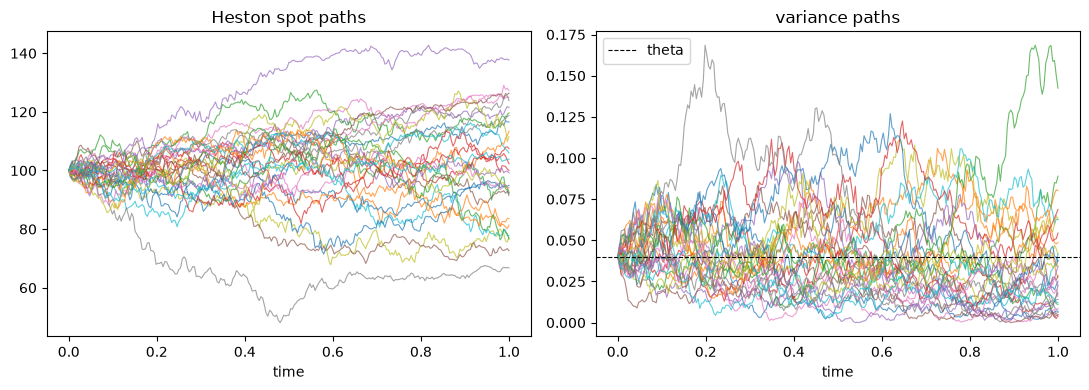

In [5]:
heston = HestonParams()  # kappa=2, theta=0.04, sigma_v=0.3, rho=-0.7
h = simulate_heston(heston, n_paths=30, n_steps=252, horizon=1.0, seed=11)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(t, h.spot.T, lw=0.8, alpha=0.7); ax1.set_title("Heston spot paths"); ax1.set_xlabel("time")
ax2.plot(t, h.variance.T, lw=0.8, alpha=0.7); ax2.axhline(heston.theta, color="k", ls="--", lw=0.8, label="theta")
ax2.set_title("variance paths"); ax2.set_xlabel("time"); ax2.legend()
plt.tight_layout(); plt.show()

### Heston sanity checks

**What you are looking at:** three asserted properties. (1) The effective
variance is non-negative everywhere — the point of full truncation. (2)
Started off its long-run level, the mean variance decays to the CIR closed
form $\theta + (v_0-\theta)e^{-\kappa T}$ (4 SE plus a 1%-of-$\theta$
discretization allowance). (3) Pooled correlation between spot log-returns
and variance changes is close to $\rho = -0.7$ — the leverage effect has the
right sign and size.

In [6]:
# (1) non-negativity
big = simulate_heston(heston, n_paths=20_000, n_steps=250, horizon=1.0, seed=1005)
assert np.all(big.variance >= 0)
print("variance non-negative everywhere")

# (2) long-run mean of variance (start off-level so the test has power)
off = HestonParams(v0=0.09)
T_long = 3.0
hl = simulate_heston(off, n_paths=20_000, n_steps=1500, horizon=T_long, seed=1006)
v_t = hl.variance[:, -1]
expected = off.theta + (off.v0 - off.theta) * np.exp(-off.kappa * T_long)
se = v_t.std(ddof=1) / np.sqrt(len(v_t))
print(f"E[v_T]: sample {v_t.mean():.5f} vs closed form {expected:.5f}  (SE {se:.5f})")
assert abs(v_t.mean() - expected) < 4 * se + 0.01 * off.theta

# (3) leverage effect
lev = simulate_heston(heston, n_paths=10_000, n_steps=250, horizon=1.0, seed=1007)
corr = np.corrcoef(np.diff(np.log(lev.spot), axis=1).ravel(),
                   np.diff(lev.variance, axis=1).ravel())[0, 1]
print(f"corr(d log S, dv) = {corr:.3f}  (rho = {heston.rho})")
assert corr < -0.6
print("Heston sanity checks passed")

variance non-negative everywhere


E[v_T]: sample 0.04027 vs closed form 0.04012  (SE 0.00021)


corr(d log S, dv) = -0.699  (rho = -0.7)
Heston sanity checks passed


## Verification summary

Every assert above has run green if you are reading executed output below.
Numeric headline claims start at Stage 3 (frozen baseline tables); until
then `CLAIMS.md` is empty by design, so this notebook verifies *model
properties* rather than published numbers. The same checks are enforced in
CI via `uv run pytest -m gate_stage1`.

In [7]:
print("01_simulators: all assertions passed")

01_simulators: all assertions passed
